## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Load Dataset

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore Data

In [3]:
df.shape

(891, 12)

In [4]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Preprocessing

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Cabin'] = df['Cabin'].fillna('Unknown')

In [10]:
df.drop(
    ['PassengerId','Name','Ticket','Cabin'],
    axis=1,
    inplace=True
)

In [11]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

## Feature Engineering

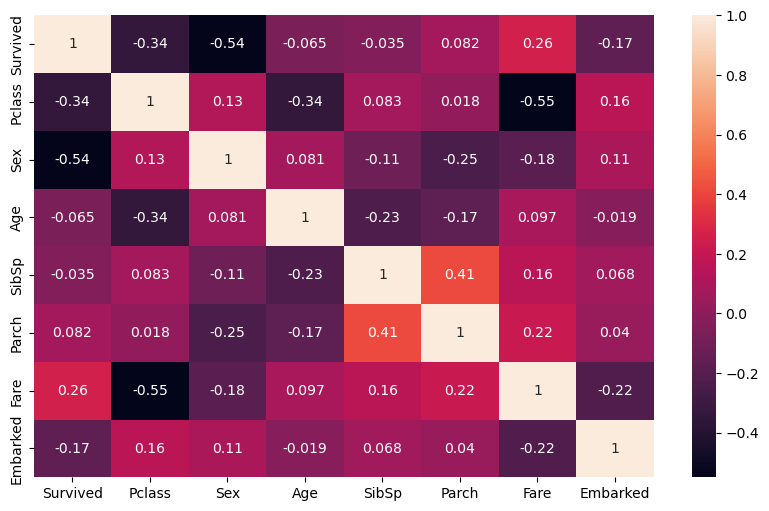

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

## Features such as Sex, Fare, and Pclass show stronger relationships with survival and are important predictors.

## Split Dataset

In [13]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model 1 — Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

## Model 2 — Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

## Model 3 — KNN

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [21]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred)

knn_recall = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)

## Comparison Table

In [22]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Accuracy':[
        lr_accuracy,
        rf_accuracy,
        knn_accuracy
    ],
    'Precision':[
        lr_precision,
        rf_precision,
        knn_precision
    ],
    'Recall':[
        lr_recall,
        rf_recall,
        knn_recall
    ],
    'F1 Score':[
        lr_f1,
        rf_f1,
        knn_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Random Forest,0.821229,0.808824,0.743243,0.774648
2,KNN,0.720670,0.714286,0.540541,0.615385


## Best Model Analysis

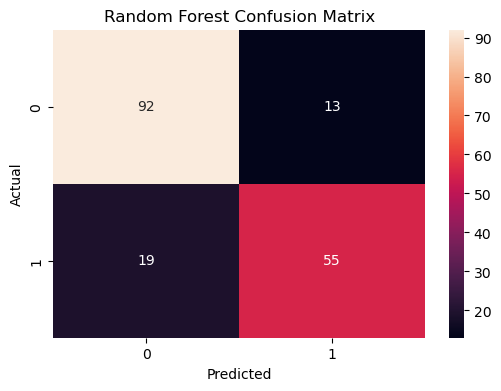

In [23]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

## Insights
1. Random Forest achieved the highest accuracy among the three models.

2. Logistic Regression provided good performance with simpler computation.

3. KNN performed reasonably but was less accurate than Random Forest.

4. Passenger class, gender, and fare were important survival predictors.

5. Ensemble methods improved prediction performance.

## Conclusion

Three machine learning models were trained and evaluated on the Titanic dataset. 
Random Forest achieved the best overall performance based on accuracy and F1 score. 
Feature analysis showed that passenger class, gender, and fare significantly influenced survival outcomes. 
Logistic Regression also performed well but was slightly less accurate. 
Therefore, Random Forest is recommended as the best model for this prediction task.